STUDENT PLACEMENT PREDICTION SYSTEM
PHASE 1.5 — MODEL INFERENCE & VALIDATION

CONFIGURATION
--------------------------------------------------------------------------------
Project directory : C:\Users\ASUS\My_Learning\MLops project
Dataset           : C:\Users\ASUS\My_Learning\MLops project\students.csv
Model             : C:\Users\ASUS\My_Learning\MLops project\models\placement_pipeline.pkl
Feature info      : C:\Users\ASUS\My_Learning\MLops project\models\feature_information.pkl
Results directory : C:\Users\ASUS\My_Learning\MLops project\reports\inference
Target column     : Placement Status

CHECKING REQUIRED FILES
✓ Found:
   C:\Users\ASUS\My_Learning\MLops project\students.csv
✓ Found:
   C:\Users\ASUS\My_Learning\MLops project\models\placement_pipeline.pkl
✓ Found:
   C:\Users\ASUS\My_Learning\MLops project\models\feature_information.pkl

CHECKING MODEL FILE
Model file size: 64,442 bytes

LOADING SAVED MODEL
✓ Model loaded using joblib.

Model type:
<class 'sklearn.pipeline.Pipe

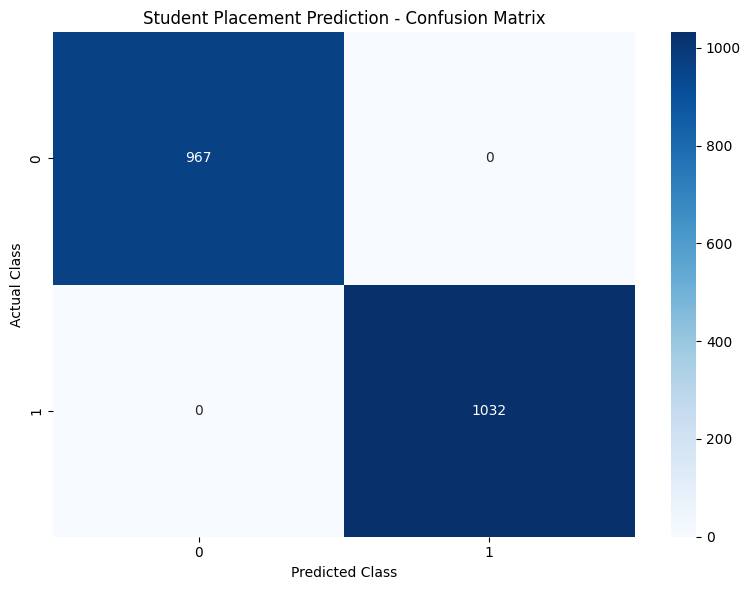


✓ Confusion matrix saved:
C:\Users\ASUS\My_Learning\MLops project\reports\inference\inference_confusion_matrix.png

CREATING PREDICTION RESULTS

SAMPLE PREDICTIONS
                          Student ID                Name Placement Status Actual_Placement Predicted_Placement  Placement_Probability  Prediction_Correct
b37412a3-fa5c-40ca-b087-7109a47482d7                Amit       Not Placed       Not Placed          Not Placed               0.000031                True
65001423-faeb-4d19-a550-8ea26133a34d        Tina Ballard       Not Placed       Not Placed          Not Placed               0.001167                True
228aaf1d-8710-4c8d-bfec-001b0df01f34               Meena       Not Placed       Not Placed          Not Placed               0.000129                True
1aa67474-e200-4157-ad54-c95aaa4d52a8 Christopher Morales           Placed           Placed              Placed               0.979837                True
5122db4a-14c8-44d7-b2f4-e869f69d3dd7           Siddharth       No

In [7]:
# ============================================================
# PHASE 1.5 — MODEL INFERENCE & VALIDATION
# STUDENT PLACEMENT PREDICTION SYSTEM
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import pickle
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


print("=" * 80)
print("STUDENT PLACEMENT PREDICTION SYSTEM")
print("PHASE 1.5 — MODEL INFERENCE & VALIDATION")
print("=" * 80)


# ============================================================
# 2. CONFIGURATION
# ============================================================

# IMPORTANT:
# Use the SAME project directory used during Phase 1.

PROJECT_DIR = r"C:\Users\ASUS\My_Learning\MLops project"

DATA_PATH = os.path.join(
    PROJECT_DIR,
    "students.csv"
)

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "placement_pipeline.pkl"
)

FEATURE_INFO_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "feature_information.pkl"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "reports",
    "inference"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

TARGET_COLUMN = "Placement Status"


print("\nCONFIGURATION")
print("-" * 80)

print("Project directory :", PROJECT_DIR)
print("Dataset           :", DATA_PATH)
print("Model             :", MODEL_PATH)
print("Feature info      :", FEATURE_INFO_PATH)
print("Results directory :", RESULTS_DIR)
print("Target column     :", TARGET_COLUMN)


# ============================================================
# 3. CHECK REQUIRED FILES
# ============================================================

print("\n" + "=" * 80)
print("CHECKING REQUIRED FILES")
print("=" * 80)


required_files = [
    DATA_PATH,
    MODEL_PATH,
    FEATURE_INFO_PATH
]


missing_files = []


for file_path in required_files:

    if os.path.exists(file_path):

        print("✓ Found:")
        print("  ", file_path)

    else:

        print("✗ Missing:")
        print("  ", file_path)

        missing_files.append(file_path)


if missing_files:

    print("\nMissing files:")

    for file_path in missing_files:
        print(" -", file_path)

    raise FileNotFoundError(
        "\nRequired files are missing. "
        "Check PROJECT_DIR and make sure they match Phase 1."
    )


# ============================================================
# 4. CHECK MODEL FILE
# ============================================================

print("\n" + "=" * 80)
print("CHECKING MODEL FILE")
print("=" * 80)


model_size = os.path.getsize(
    MODEL_PATH
)

print(
    f"Model file size: {model_size:,} bytes"
)


if model_size == 0:

    raise ValueError(
        "The model file is empty. "
        "Re-run Phase 1 and save the model again."
    )


# ============================================================
# 5. LOAD SAVED MODEL
# ============================================================

print("\n" + "=" * 80)
print("LOADING SAVED MODEL")
print("=" * 80)


try:

    pipeline = joblib.load(
        MODEL_PATH
    )

    print(
        "✓ Model loaded using joblib."
    )

except Exception as joblib_error:

    print(
        "\njoblib.load() failed."
    )

    print(
        "Trying pickle.load()..."
    )

    try:

        with open(
            MODEL_PATH,
            "rb"
        ) as f:

            pipeline = pickle.load(f)

        print(
            "✓ Model loaded using pickle."
        )

    except Exception as pickle_error:

        raise RuntimeError(
            "\nCould not load the saved model.\n\n"
            f"Joblib error: {joblib_error}\n\n"
            f"Pickle error: {pickle_error}"
        )


print("\nModel type:")
print(type(pipeline))


# ============================================================
# 6. LOAD FEATURE INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("LOADING FEATURE INFORMATION")
print("=" * 80)


try:

    feature_info = joblib.load(
        FEATURE_INFO_PATH
    )

    print(
        "✓ Feature information loaded using joblib."
    )

except Exception:

    with open(
        FEATURE_INFO_PATH,
        "rb"
    ) as f:

        feature_info = pickle.load(f)

    print(
        "✓ Feature information loaded using pickle."
    )


print("\nFeature information:")

print(
    feature_info
)


# ============================================================
# 7. LOAD DATASET
# ============================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)


df = pd.read_csv(
    DATA_PATH
)


print(
    "Dataset shape:",
    df.shape
)


print("\nDataset columns:")

for i, column in enumerate(
    df.columns,
    start=1
):

    print(
        f"{i:02d}. {column}"
    )


# ============================================================
# 8. VERIFY TARGET COLUMN
# ============================================================

print("\n" + "=" * 80)
print("TARGET COLUMN CHECK")
print("=" * 80)


if TARGET_COLUMN not in df.columns:

    raise ValueError(
        f"Target column '{TARGET_COLUMN}' "
        "was not found in the dataset."
    )


print(
    "✓ Target column found:",
    TARGET_COLUMN
)


# ============================================================
# 9. INSPECT TARGET VALUES
# ============================================================

print("\n" + "=" * 80)
print("ORIGINAL TARGET VALUES")
print("=" * 80)


print(
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
)


print("\nUnique target values:")

print(
    df[TARGET_COLUMN]
    .unique()
)


print(
    "\nNumber of unique target values:",
    df[TARGET_COLUMN].nunique(dropna=True)
)


# ============================================================
# 10. REMOVE ROWS WITH MISSING TARGET
# ============================================================
#
# IMPORTANT:
# Phase 1 dropped rows where the target was missing before
# training. This script must do the same before building X/y,
# otherwise those rows carry a real NaN all the way through
# encoding and trip the final "could not be encoded" check
# even though every actual label was recognized correctly.
# ============================================================

print("\n" + "=" * 80)
print("CHECKING FOR MISSING TARGET VALUES")
print("=" * 80)


target_missing_count = df[TARGET_COLUMN].isna().sum()

print(
    "Rows with missing target:",
    target_missing_count
)

if target_missing_count > 0:

    print(
        f"\nDropping {target_missing_count} rows with a missing "
        f"'{TARGET_COLUMN}' value before running inference."
    )

    df = df.dropna(
        subset=[TARGET_COLUMN]
    ).reset_index(drop=True)

    print(
        "Dataset shape after dropping missing-target rows:",
        df.shape
    )

else:

    print("✓ No missing target values found.")


# ============================================================
# 11. INSPECT IMPORTANT CATEGORICAL FEATURES
# ============================================================

print("\n" + "=" * 80)
print("CATEGORICAL FEATURE INSPECTION")
print("=" * 80)


categorical_columns_to_check = [

    "Gender",

    "Branch",

    "Clubs",

    "Skills",

    "Internship Done",

    "Internship Domain",

    "Alumni Path"

]


for column in categorical_columns_to_check:

    if column in df.columns:

        print("\n" + "-" * 70)

        print(column)

        print("-" * 70)

        print(
            df[column]
            .value_counts(
                dropna=False
            )
            .head(20)
        )


# ============================================================
# 12. IDENTIFY MODEL FEATURES
# ============================================================

print("\n" + "=" * 80)
print("IDENTIFYING MODEL FEATURES")
print("=" * 80)


feature_columns = None


# ------------------------------------------------------------
# Try to retrieve feature columns directly
# ------------------------------------------------------------

if isinstance(
    feature_info,
    dict
):

    possible_keys = [

        "feature_columns",

        "features",

        "input_features",

        "selected_features",

        "feature_names"

    ]


    for key in possible_keys:

        if key in feature_info:

            value = feature_info[key]

            if isinstance(
                value,
                (list, tuple, np.ndarray)
            ):

                feature_columns = list(
                    value
                )

                print(
                    f"✓ Feature list found under: '{key}'"
                )

                break


# ------------------------------------------------------------
# If not found, combine numerical and categorical features
# ------------------------------------------------------------

if feature_columns is None:

    if isinstance(
        feature_info,
        dict
    ):

        combined_features = []


        for key in [
            "numerical_features",
            "categorical_features"
        ]:

            if key in feature_info:

                value = feature_info[key]


                if isinstance(
                    value,
                    (list, tuple, np.ndarray)
                ):

                    combined_features.extend(
                        list(value)
                    )


        if combined_features:

            feature_columns = combined_features

            print(
                "✓ Feature list reconstructed "
                "from numerical_features + categorical_features."
            )


# ------------------------------------------------------------
# Final fallback
# ------------------------------------------------------------

if feature_columns is None:

    print(
        "⚠ Feature list was not found in feature_information.pkl."
    )

    print(
        "Reconstructing using Phase 1 exclusions..."
    )


    columns_to_remove = [

        "Student ID",

        "Name",

        "Placement Domain",

        "CTC (LPA)",

        TARGET_COLUMN

    ]


    feature_columns = [

        column

        for column in df.columns

        if column not in columns_to_remove

    ]


# ------------------------------------------------------------
# Remove accidental duplicates
# ------------------------------------------------------------

feature_columns = list(
    dict.fromkeys(
        feature_columns
    )
)


print("\nMODEL INPUT FEATURES")

for i, feature in enumerate(
    feature_columns,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


print(
    "\nTotal input features:",
    len(feature_columns)
)


# ============================================================
# 13. VERIFY FEATURES EXIST
# ============================================================

print("\n" + "=" * 80)
print("VERIFYING FEATURES")
print("=" * 80)


missing_features = [

    feature

    for feature in feature_columns

    if feature not in df.columns

]


if missing_features:

    print(
        "Missing features:"
    )

    for feature in missing_features:

        print(
            " -",
            feature
        )


    raise ValueError(
        "\nSome model features are missing from the dataset."
    )


print(
    "✓ All model features exist in the dataset."
)


# ============================================================
# 14. CREATE INPUT DATA
# ============================================================

print("\n" + "=" * 80)
print("CREATING MODEL INPUT DATA")
print("=" * 80)


X = df[
    feature_columns
].copy()


y_original = df[
    TARGET_COLUMN
].copy()


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y_original.shape
)


# ============================================================
# 15. TARGET ENCODING
# ============================================================

print("\n" + "=" * 80)
print("PROCESSING TARGET")
print("=" * 80)


print("\nOriginal target distribution:")

print(
    y_original
    .value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# Normalize target values
# ------------------------------------------------------------

def normalize_label(value):

    if pd.isna(value):

        return np.nan

    return str(
        value
    ).strip().lower()


normalized_target = (
    y_original
    .apply(normalize_label)
)


# ------------------------------------------------------------
# Known binary labels
# ------------------------------------------------------------

POSITIVE_LABELS = {

    "placed",
    "yes",
    "y",
    "true",
    "1",
    "selected",
    "successful",
    "placement"

}


NEGATIVE_LABELS = {

    "not placed",
    "not_placed",
    "notplaced",
    "no",
    "n",
    "false",
    "0",
    "not selected",
    "unsuccessful"

}


# ------------------------------------------------------------
# Try binary mapping
# ------------------------------------------------------------

y_binary = normalized_target.map(

    lambda value:

        1 if value in POSITIVE_LABELS

        else (

            0
            if value in NEGATIVE_LABELS

            else np.nan
        )

)


# ============================================================
# 16. DETERMINE WHETHER TARGET IS BINARY OR MULTICLASS
# ============================================================

print("\n" + "=" * 80)
print("DETERMINING TARGET TYPE")
print("=" * 80)


if not y_binary.isna().any():

    # All labels matched our keyword-based binary mapping.
    # (At this point, rows with a genuinely missing target
    # have already been dropped in step 10, so this only
    # covers real label text.)

    y = y_binary.astype(int)

    target_type = "binary"

    # Define class_to_number here too so downstream sections
    # (which reference it for display/reporting) always have
    # it available, regardless of which branch was taken.
    class_to_number = {
        "Not Placed": 0,
        "Placed": 1
    }

    print(
        "✓ Target detected as BINARY classification "
        "(matched entirely via keyword rules)."
    )


else:

    # Some labels did not match the keyword rules.
    # Inspect the actual number of unique values.

    unique_labels = (
        normalized_target
        .dropna()
        .unique()
    )


    print(
        "\nLabels not recognized by the binary mapping:"
    )

    print(
        normalized_target[
            y_binary.isna()
        ]
        .value_counts()
    )


    if len(unique_labels) == 2:

        # ----------------------------------------------------
        # Exactly two classes.
        # Automatically encode them.
        # ----------------------------------------------------

        print(
            "\nExactly 2 classes detected."
        )

        print(
            "Using automatic binary encoding."
        )


        class_values = sorted(
            unique_labels
        )


        class_to_number = {

            class_values[0]: 0,

            class_values[1]: 1

        }


        y = normalized_target.map(
            class_to_number
        )


        target_type = "binary"


        print(
            "\nAutomatic mapping:"
        )


        for label, encoded in class_to_number.items():

            print(
                f"  {label!r} -> {encoded}"
            )


        print(
            "\n⚠ Verify that class 1 represents PLACED."
        )


    else:

        # ----------------------------------------------------
        # More than two classes.
        # Treat as multiclass.
        # ----------------------------------------------------

        print(
            f"\n{len(unique_labels)} classes detected."
        )

        print(
            "Target will be treated as MULTICLASS."
        )


        class_values = sorted(
            unique_labels
        )


        class_to_number = {

            label: index

            for index, label
            in enumerate(class_values)

        }


        y = normalized_target.map(
            class_to_number
        )


        target_type = "multiclass"


        print(
            "\nMulticlass mapping:"
        )


        for label, encoded in class_to_number.items():

            print(
                f"  {label!r} -> {encoded}"
            )


# ------------------------------------------------------------
# Check for invalid target values
# ------------------------------------------------------------

if y.isna().any():

    print(
        "\nInvalid target values:"
    )

    print(
        y_original[
            y.isna()
        ]
        .value_counts(
            dropna=False
        )
    )

    print(
        "\nIf any of the values above are blank/NaN, that means "
        "there are still missing-target rows slipping through — "
        "double check step 10 ran and dropped them. If instead "
        "they are real text values, add them to POSITIVE_LABELS / "
        "NEGATIVE_LABELS in step 15, or note that a >2-class "
        "target requires the multiclass path above to have run."
    )

    raise ValueError(
        "Some target values could not be encoded."
    )


y = y.astype(int)


# ============================================================
# 17. FINAL TARGET INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL TARGET INFORMATION")
print("=" * 80)


print(
    "Target type:",
    target_type
)


print(
    "Number of classes:",
    y.nunique()
)


print(
    "\nEncoded target distribution:"
)


print(
    y.value_counts()
    .sort_index()
)


print(
    "\nClass mapping:"
)


for label, encoded in class_to_number.items():

    print(
        f"  {label!r} -> {encoded}"
    )


# ============================================================
# 18. RUN MODEL PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("RUNNING MODEL PREDICTIONS")
print("=" * 80)


print(
    "Generating predictions..."
)


predictions = pipeline.predict(
    X
)


predictions = np.asarray(
    predictions
)


print(
    "✓ Predictions generated."
)


print(
    "\nPrediction distribution:"
)


print(
    pd.Series(
        predictions
    )
    .value_counts()
    .sort_index()
)


# ============================================================
# 19. CHECK TARGET AND PREDICTION COMPATIBILITY
# ============================================================

print("\n" + "=" * 80)
print("CHECKING TARGET / PREDICTION COMPATIBILITY")
print("=" * 80)


print(
    "Actual classes:",
    sorted(
        np.unique(y)
    )
)


print(
    "Predicted classes:",
    sorted(
        np.unique(predictions)
    )
)


# ============================================================
# 20. PREDICTION PROBABILITIES
# ============================================================

print("\n" + "=" * 80)
print("GENERATING PREDICTION PROBABILITIES")
print("=" * 80)


prediction_probabilities = None


if hasattr(
    pipeline,
    "predict_proba"
):

    try:

        probabilities = pipeline.predict_proba(
            X
        )


        prediction_probabilities = probabilities


        print(
            "✓ Prediction probabilities generated."
        )


        print(
            "Probability shape:",
            probabilities.shape
        )


    except Exception as e:

        print(
            "⚠ Could not generate probabilities."
        )

        print(
            "Error:",
            e
        )


else:

    print(
        "Model does not provide predict_proba()."
    )


# ============================================================
# 21. CALCULATE ACCURACY
# ============================================================

print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)


accuracy = accuracy_score(
    y,
    predictions
)


# ============================================================
# 22. CALCULATE PRECISION / RECALL / F1
# ============================================================

if target_type == "binary":

    print(
        "\nBinary classification metrics selected."
    )


    precision = precision_score(

        y,

        predictions,

        average="binary",

        zero_division=0

    )


    recall = recall_score(

        y,

        predictions,

        average="binary",

        zero_division=0

    )


    f1 = f1_score(

        y,

        predictions,

        average="binary",

        zero_division=0

    )


else:

    print(
        "\nMulticlass classification metrics selected."
    )


    precision = precision_score(

        y,

        predictions,

        average="weighted",

        zero_division=0

    )


    recall = recall_score(

        y,

        predictions,

        average="weighted",

        zero_division=0

    )


    f1 = f1_score(

        y,

        predictions,

        average="weighted",

        zero_division=0

    )


# ============================================================
# 23. ROC-AUC
# ============================================================

roc_auc = np.nan


if prediction_probabilities is not None:

    try:

        if target_type == "binary":

            # Find probability corresponding to class 1

            model_classes = None


            if hasattr(
                pipeline,
                "classes_"
            ):

                model_classes = (
                    pipeline.classes_
                )


            if model_classes is not None:

                model_classes = list(
                    model_classes
                )


                if 1 in model_classes:

                    positive_index = (
                        model_classes.index(1)
                    )


                    positive_probability = (
                        prediction_probabilities[
                            :,
                            positive_index
                        ]
                    )


                    roc_auc = roc_auc_score(

                        y,

                        positive_probability

                    )


                else:

                    print(
                        "⚠ Model does not contain class 1."
                    )

            else:

                # Fallback

                if prediction_probabilities.shape[1] == 2:

                    roc_auc = roc_auc_score(

                        y,

                        prediction_probabilities[:, 1]

                    )


        else:

            # Multiclass ROC-AUC

            roc_auc = roc_auc_score(

                y,

                prediction_probabilities,

                multi_class="ovr",

                average="weighted"

            )


    except Exception as e:

        print(
            "\n⚠ ROC-AUC could not be calculated."
        )

        print(
            "Reason:",
            e
        )


# ============================================================
# 24. DISPLAY FINAL METRICS
# ============================================================

print("\n" + "-" * 80)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


if not np.isnan(
    roc_auc
):

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )

else:

    print(
        "ROC-AUC   : Not available"
    )


# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)


print(
    classification_report(

        y,

        predictions,

        zero_division=0

    )
)


# ============================================================
# 26. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)


cm = confusion_matrix(

    y,

    predictions

)


print(
    "\nConfusion Matrix:"
)

print(
    cm
)


# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    cbar=True

)


plt.title(
    "Student Placement Prediction - Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


plt.tight_layout()


cm_path = os.path.join(

    RESULTS_DIR,

    "inference_confusion_matrix.png"

)


plt.savefig(

    cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "\n✓ Confusion matrix saved:"
)

print(
    cm_path
)


# ============================================================
# 27. CREATE RESULTS DATAFRAME
# ============================================================

print("\n" + "=" * 80)
print("CREATING PREDICTION RESULTS")
print("=" * 80)


results = df.copy()


results[
    "Actual_Target"
] = y


results[
    "Predicted_Target"
] = predictions


# ------------------------------------------------------------
# Binary / multiclass labels (same logic either way)
# ------------------------------------------------------------

inverse_mapping = {
    encoded: label
    for label, encoded
    in class_to_number.items()
}


results[
    "Actual_Placement"
] = [

    inverse_mapping.get(
        value,
        str(value)
    )

    for value in y

]


results[
    "Predicted_Placement"
] = [

    inverse_mapping.get(
        value,
        str(value)
    )

    for value in predictions

]


# ------------------------------------------------------------
# Probability
# ------------------------------------------------------------

if prediction_probabilities is not None:

    if target_type == "binary":

        if prediction_probabilities.shape[1] == 2:

            if hasattr(
                pipeline,
                "classes_"
            ):

                model_classes = list(
                    pipeline.classes_
                )

                if 1 in model_classes:

                    positive_index = (
                        model_classes.index(1)
                    )

                    results[
                        "Placement_Probability"
                    ] = (
                        prediction_probabilities[
                            :,
                            positive_index
                        ]
                    )


# ------------------------------------------------------------
# Prediction correctness
# ------------------------------------------------------------

results[
    "Prediction_Correct"
] = (

    results[
        "Actual_Target"
    ]

    ==

    results[
        "Predicted_Target"
    ]

)


# ============================================================
# 28. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)


display_columns = []


for column in [

    "Student ID",

    "Name",

    "Placement Status",

    "Actual_Placement",

    "Predicted_Placement",

    "Placement_Probability",

    "Prediction_Correct"

]:

    if column in results.columns:

        display_columns.append(
            column
        )


print(

    results[
        display_columns
    ]
    .head(20)
    .to_string(
        index=False
    )

)


# ============================================================
# 29. SAVE INFERENCE RESULTS
# ============================================================

print("\n" + "=" * 80)
print("SAVING INFERENCE RESULTS")
print("=" * 80)


results_path = os.path.join(

    RESULTS_DIR,

    "inference_results.csv"

)


results.to_csv(

    results_path,

    index=False

)


print(
    "✓ Inference results saved:"
)

print(
    results_path
)


# ============================================================
# 30. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"

    ],

    "Value": [

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})


metrics_path = os.path.join(

    RESULTS_DIR,

    "inference_metrics.csv"

)


metrics.to_csv(

    metrics_path,

    index=False

)


print(
    "\n✓ Metrics saved:"
)

print(
    metrics_path
)


# ============================================================
# 31. CREATE SINGLE NEW STUDENT
# ============================================================

print("\n" + "=" * 80)
print("SINGLE NEW STUDENT PREDICTION")
print("=" * 80)


print(
    """
For this first test, an existing student is used as the
example input so that all categorical values are guaranteed
to match the training data.

Later, replace these values with a completely new student.
"""
)


sample_student = df.iloc[0]


new_student = {}


for feature in feature_columns:

    new_student[
        feature
    ] = sample_student[
        feature
    ]


new_student_df = pd.DataFrame(

    [new_student]

)


print(
    "\nNew student input:"
)


print(

    new_student_df
    .to_string(
        index=False
    )

)


# ============================================================
# 32. PREDICT NEW STUDENT
# ============================================================

new_prediction = pipeline.predict(

    new_student_df

)[0]


print(
    "\nPredicted encoded class:",
    new_prediction
)


print(
    "Predicted class label:",
    inverse_mapping.get(
        new_prediction,
        str(new_prediction)
    )
)


# ============================================================
# 33. NEW STUDENT PROBABILITY
# ============================================================

if hasattr(

    pipeline,

    "predict_proba"

):

    try:

        new_probability = (
            pipeline.predict_proba(
                new_student_df
            )[0]
        )


        print(
            "\nPrediction probabilities:"
        )


        if hasattr(
            pipeline,
            "classes_"
        ):

            model_classes = list(
                pipeline.classes_
            )


            for class_value, probability in zip(

                model_classes,

                new_probability

            ):

                class_label = (
                    inverse_mapping.get(
                        class_value,
                        str(class_value)
                    )
                )


                print(

                    f"  {class_label}: "
                    f"{probability:.2%}"

                )


    except Exception as e:

        print(
            "Could not calculate new-student probability:"
        )

        print(
            e
        )


# ============================================================
# 34. TEST MULTIPLE EXISTING STUDENTS
# ============================================================

print("\n" + "=" * 80)
print("MULTIPLE STUDENT INFERENCE TEST")
print("=" * 80)


sample_size = min(

    10,

    len(X)

)


sample_X = X.head(
    sample_size
)


sample_predictions = pipeline.predict(

    sample_X

)


sample_output = sample_X.copy()


sample_output[
    "Predicted_Target"
] = sample_predictions


sample_output[
    "Predicted_Placement"
] = [

    inverse_mapping.get(
        value,
        str(value)
    )

    for value in sample_predictions

]


print(

    sample_output
    .to_string(
        index=False
    )

)


# ============================================================
# 35. INCORRECT PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("INCORRECT PREDICTIONS")
print("=" * 80)


incorrect_predictions = results[

    results[
        "Prediction_Correct"
    ] == False

]


correct_predictions = results[

    results[
        "Prediction_Correct"
    ] == True

]


print(
    "Correct predictions   :",
    len(correct_predictions)
)


print(
    "Incorrect predictions :",
    len(incorrect_predictions)
)


print(
    "Total samples         :",
    len(results)
)


error_rate = (

    len(incorrect_predictions)

    /

    len(results)

)


print(
    "Error rate            :",
    f"{error_rate:.2%}"
)


# ============================================================
# 36. SAVE INCORRECT PREDICTIONS
# ============================================================

incorrect_path = os.path.join(

    RESULTS_DIR,

    "incorrect_predictions.csv"

)


incorrect_predictions.to_csv(

    incorrect_path,

    index=False

)


print(
    "\n✓ Incorrect predictions saved:"
)

print(
    incorrect_path
)


# ============================================================
# 37. SAVE CLASS MAPPING
# ============================================================

mapping_df = pd.DataFrame({

    "Original_Label": list(
        class_to_number.keys()
    ),

    "Encoded_Value": list(
        class_to_number.values()
    )

})


mapping_path = os.path.join(

    RESULTS_DIR,

    "target_class_mapping.csv"

)


mapping_df.to_csv(

    mapping_path,

    index=False

)


print(
    "\n✓ Target mapping saved:"
)

print(
    mapping_path
)


# ============================================================
# 38. FINAL VALIDATION SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PHASE 1.5 — FINAL VALIDATION SUMMARY")
print("=" * 80)


print(
    f"""
Dataset samples       : {len(df)}
Input features        : {len(feature_columns)}
Target type           : {target_type}
Number of classes     : {y.nunique()}

Accuracy              : {accuracy:.4f}
Precision             : {precision:.4f}
Recall                : {recall:.4f}
F1 Score              : {f1:.4f}
ROC-AUC               : {
    f"{roc_auc:.4f}"
    if not np.isnan(roc_auc)
    else "Not available"
}

Correct predictions   : {len(correct_predictions)}
Incorrect predictions : {len(incorrect_predictions)}
Error rate            : {error_rate:.2%}
"""
)


# ============================================================
# 39. MODEL STATUS
# ============================================================

print("=" * 80)
print("MODEL STATUS")
print("=" * 80)


if accuracy >= 0.80:

    print(
        "✓ Model inference completed successfully."
    )

    print(
        "✓ Accuracy is >= 80%."
    )

else:

    print(
        "⚠ Model inference completed."
    )

    print(
        "⚠ Accuracy is below 80%."
    )


print(
    """
The saved model successfully accepts student features
and produces placement predictions.
"""
)


# ============================================================
# 40. GENERATED ARTIFACTS
# ============================================================

print("\n" + "=" * 80)
print("GENERATED ARTIFACTS")
print("=" * 80)


print(
    f"""
models/
├── placement_pipeline.pkl
└── feature_information.pkl

reports/
└── inference/
    ├── inference_results.csv
    ├── inference_metrics.csv
    ├── incorrect_predictions.csv
    ├── target_class_mapping.csv
    └── inference_confusion_matrix.png
"""
)


# ============================================================
# 41. NEXT PHASE
# ============================================================

print("\n" + "=" * 80)
print("NEXT PHASE — MLOps")
print("=" * 80)


print(
    """
PHASE 1 — MACHINE LEARNING
✓ Dataset loading
✓ Data cleaning
✓ EDA
✓ Data preprocessing
✓ Feature engineering
✓ Model training
✓ Model comparison
✓ Hyperparameter tuning
✓ Model evaluation
✓ SHAP analysis
✓ Model saving

PHASE 1.5 — INFERENCE VALIDATION
✓ Load saved model
✓ Load feature information
✓ Load dataset
✓ Remove rows with missing target
✓ Verify features
✓ Verify target
✓ Run predictions
✓ Calculate metrics
✓ Generate confusion matrix
✓ Test new student
✓ Save inference results

PHASE 2 — MLOps
→ Git + GitHub
→ DVC
→ Data versioning
→ MLflow
→ Experiment tracking
→ Automated training
→ Model validation
→ Model quality gate
→ MLflow Model Registry
→ GitHub Actions CI/CD
→ Docker
→ FastAPI
→ Streamlit
→ Evidently monitoring
→ Data drift detection
→ Automated retraining
"""
)


print("\n" + "=" * 80)
print("✓ PHASE 1.5 COMPLETED")
print("=" * 80)

STUDENT PLACEMENT PREDICTION SYSTEM
FINAL LEAKAGE-FREE TRAINING PIPELINE

Configuration
--------------------------------------------------------------------------------
Project directory: C:\Users\ASUS\My_Learning\MLops project
Dataset: C:\Users\ASUS\My_Learning\MLops project\students.csv
Target: Placement Status

CHECKING DATASET
✓ Dataset found.

LOADING DATASET
Dataset shape: (2000, 24)

Columns:
01. Student ID
02. Name
03. Age
04. Gender
05. Branch
06. Average GPA
07. Backlogs
08. Attendance (%)
09. Clubs
10. Skills
11. Internship Done
12. Internship Domain
13. Placement Status
14. Placement Domain
15. CTC (LPA)
16. Alumni Path
17. Sem1 GPA
18. Sem2 GPA
19. Sem3 GPA
20. Sem4 GPA
21. Sem5 GPA
22. Sem6 GPA
23. Sem7 GPA
24. Sem8 GPA

BASIC DATA INSPECTION

First 5 rows:
                             Student ID                 Name   Age  Gender  \
0  b37412a3-fa5c-40ca-b087-7109a47482d7                 Amit  21.0    Male   
1  65001423-faeb-4d19-a550-8ea26133a34d         Tina Ballard  

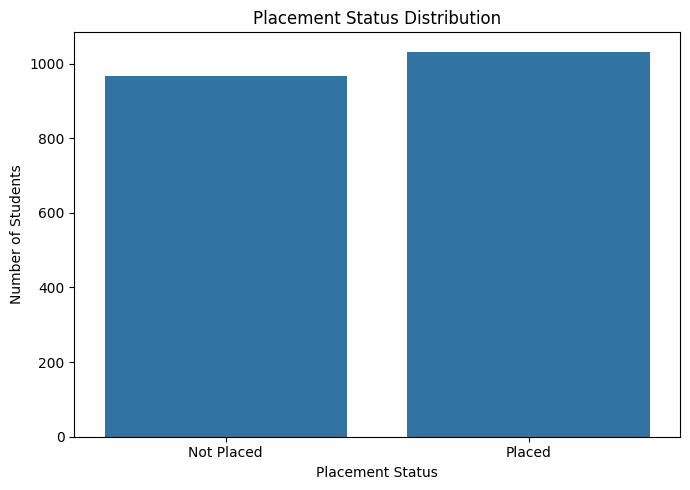


LEAKAGE ANALYSIS

Columns removed from model:
 - Student ID
 - Name
 - Placement Domain
 - CTC (LPA)
 - Placement Status

FINAL MODEL INPUT
X shape: (1999, 19)

Model features:
01. Age
02. Gender
03. Branch
04. Average GPA
05. Backlogs
06. Attendance (%)
07. Clubs
08. Skills
09. Internship Done
10. Internship Domain
11. Alumni Path
12. Sem1 GPA
13. Sem2 GPA
14. Sem3 GPA
15. Sem4 GPA
16. Sem5 GPA
17. Sem6 GPA
18. Sem7 GPA
19. Sem8 GPA

FINAL LEAKAGE CHECK
✓ No known identity/target leakage columns remain.

FEATURE TYPE DETECTION

Numerical features:
 - Age
 - Average GPA
 - Backlogs
 - Attendance (%)
 - Sem1 GPA
 - Sem2 GPA
 - Sem3 GPA
 - Sem4 GPA
 - Sem5 GPA
 - Sem6 GPA
 - Sem7 GPA
 - Sem8 GPA

Categorical features:
 - Gender
 - Branch
 - Clubs
 - Skills
 - Internship Done
 - Internship Domain
 - Alumni Path

Number of numerical features: 12
Number of categorical features: 7

CHECKING MULTI-VALUE CATEGORICAL FEATURES

Skills:
['C++, Machine Learning, Python, Java', 'C++, SQL, Web Deve

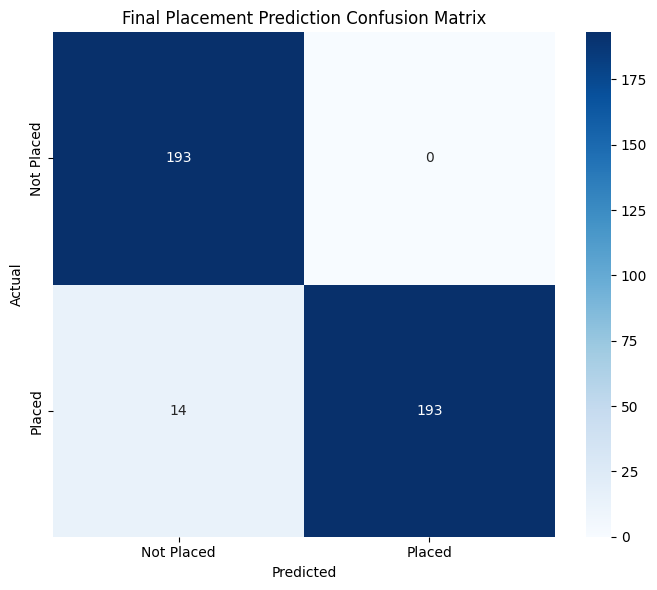

✓ Saved: C:\Users\ASUS\My_Learning\MLops project\reports\figures\final_confusion_matrix.png

ROC CURVE


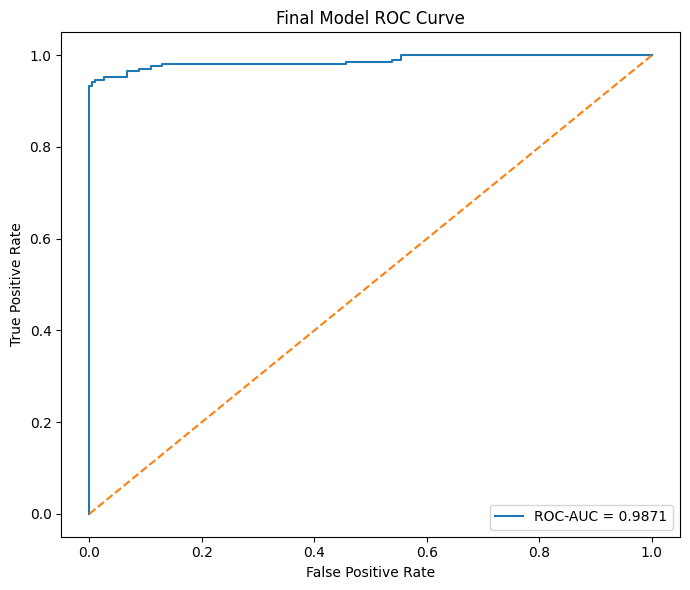

✓ Saved: C:\Users\ASUS\My_Learning\MLops project\reports\figures\final_roc_curve.png

✓ Final metrics saved:
C:\Users\ASUS\My_Learning\MLops project\reports\metrics\final_metrics.csv
✓ Test predictions saved:
C:\Users\ASUS\My_Learning\MLops project\reports\final_test_predictions.csv

SAVING FEATURE INFORMATION
✓ Feature information saved:
C:\Users\ASUS\My_Learning\MLops project\models\feature_information.pkl

SAVING FINAL MODEL
✓ Final model saved:
C:\Users\ASUS\My_Learning\MLops project\models\placement_pipeline.pkl

VERIFYING SAVED MODEL
✓ Saved model loaded successfully.

Verification predictions:
[1 1 0 0 0 1 1 0 1 1]

NEW STUDENT INFERENCE TEST

New student features:
 Age Gender Branch  Average GPA  Backlogs  Attendance (%)                                   Clubs                                            Skills Internship Done Internship Domain Alumni Path  Sem1 GPA  Sem2 GPA  Sem3 GPA  Sem4 GPA  Sem5 GPA  Sem6 GPA  Sem7 GPA  Sem8 GPA
19.0 Female  CIVIL         7.04       0.0    

In [8]:
# ============================================================
# FINAL ML TRAINING PIPELINE
# STUDENT PLACEMENT PREDICTION SYSTEM
#
# NOTEBOOK:
# 03_final_training_pipeline.ipynb
#
# PURPOSE:
# Build a leakage-free placement prediction model
# and save the complete preprocessing + model pipeline.
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import pickle
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


print("=" * 80)
print("STUDENT PLACEMENT PREDICTION SYSTEM")
print("FINAL LEAKAGE-FREE TRAINING PIPELINE")
print("=" * 80)


# ============================================================
# 2. CONFIGURATION
# ============================================================

PROJECT_DIR = r"C:\Users\ASUS\My_Learning\MLops project"

DATA_PATH = os.path.join(
    PROJECT_DIR,
    "students.csv"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

FIGURES_DIR = os.path.join(
    REPORT_DIR,
    "figures"
)

METRICS_DIR = os.path.join(
    REPORT_DIR,
    "metrics"
)


# Create directories

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    REPORT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


TARGET_COLUMN = "Placement Status"


print("\nConfiguration")
print("-" * 80)

print(
    "Project directory:",
    PROJECT_DIR
)

print(
    "Dataset:",
    DATA_PATH
)

print(
    "Target:",
    TARGET_COLUMN
)


# ============================================================
# 3. CHECK DATASET
# ============================================================

print("\n" + "=" * 80)
print("CHECKING DATASET")
print("=" * 80)


if not os.path.exists(DATA_PATH):

    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )


print(
    "✓ Dataset found."
)


# ============================================================
# 4. LOAD DATASET
# ============================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)


df = pd.read_csv(
    DATA_PATH
)


print(
    "Dataset shape:",
    df.shape
)


print("\nColumns:")

for i, column in enumerate(
    df.columns,
    start=1
):

    print(
        f"{i:02d}. {column}"
    )


# ============================================================
# 5. BASIC DATA INSPECTION
# ============================================================

print("\n" + "=" * 80)
print("BASIC DATA INSPECTION")
print("=" * 80)


print("\nFirst 5 rows:")

print(
    df.head()
)


print("\nData types:")

print(
    df.dtypes
)


print("\nMissing values:")

print(
    df.isnull()
    .sum()
)


print("\nDuplicate rows:")

print(
    df.duplicated()
    .sum()
)


# ============================================================
# 6. REMOVE EXACT DUPLICATES
# ============================================================

print("\n" + "=" * 80)
print("REMOVING DUPLICATE ROWS")
print("=" * 80)


before_duplicates = len(df)


df = df.drop_duplicates()


after_duplicates = len(df)


print(
    "Rows before:",
    before_duplicates
)

print(
    "Rows after:",
    after_duplicates
)

print(
    "Duplicates removed:",
    before_duplicates - after_duplicates
)


# ============================================================
# 7. CHECK TARGET
# ============================================================

print("\n" + "=" * 80)
print("TARGET ANALYSIS")
print("=" * 80)


if TARGET_COLUMN not in df.columns:

    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found."
    )


print(
    "\nPlacement Status values:"
)


print(
    df[TARGET_COLUMN]
    .value_counts(
        dropna=False
    )
)


print(
    "\nUnique target values:"
)

print(
    df[TARGET_COLUMN]
    .unique()
)


# ============================================================
# 8. REMOVE ROWS WITH MISSING TARGET
# ============================================================

print("\n" + "=" * 80)
print("REMOVING MISSING TARGET ROWS")
print("=" * 80)


before_target_cleanup = len(df)


df = df[
    df[TARGET_COLUMN].notna()
].copy()


after_target_cleanup = len(df)


print(
    "Rows removed:",
    before_target_cleanup - after_target_cleanup
)


print(
    "Final dataset shape:",
    df.shape
)


# ============================================================
# 9. TARGET ENCODING
# ============================================================

print("\n" + "=" * 80)
print("TARGET ENCODING")
print("=" * 80)


def normalize_label(value):

    return str(
        value
    ).strip().lower()


normalized_target = (
    df[TARGET_COLUMN]
    .apply(normalize_label)
)


POSITIVE_LABELS = {

    "placed",
    "yes",
    "y",
    "true",
    "1",
    "selected",
    "successful",
    "placement"

}


NEGATIVE_LABELS = {

    "not placed",
    "not_placed",
    "notplaced",
    "no",
    "n",
    "false",
    "0",
    "not selected",
    "unsuccessful"

}


# ------------------------------------------------------------
# Try known binary mapping
# ------------------------------------------------------------

y = normalized_target.map(

    lambda value:

        1
        if value in POSITIVE_LABELS

        else (

            0
            if value in NEGATIVE_LABELS

            else np.nan

        )

)


# ------------------------------------------------------------
# If mapping failed, inspect classes
# ------------------------------------------------------------

if y.isna().any():

    unique_labels = sorted(
        normalized_target.unique()
    )


    print(
        "\nSome labels were not recognized:"
    )


    print(
        normalized_target[
            y.isna()
        ]
        .value_counts()
    )


    if len(unique_labels) == 2:

        print(
            "\nExactly two classes detected."
        )

        print(
            "Using automatic binary encoding."
        )


        class_to_number = {

            unique_labels[0]: 0,

            unique_labels[1]: 1

        }


        y = normalized_target.map(
            class_to_number
        )


        print(
            "\nAutomatic target mapping:"
        )


        for label, number in class_to_number.items():

            print(
                f"{label} -> {number}"
            )


        print(
            "\nIMPORTANT:"
        )

        print(
            "Make sure encoded class 1 means PLACED."
        )


    else:

        raise ValueError(
            "Target appears to contain more than "
            "two classes. Check Placement Status."
        )


else:

    class_to_number = {

        "not placed": 0,

        "placed": 1

    }


y = y.astype(int)


print(
    "\nFinal target distribution:"
)


print(
    y.value_counts()
    .sort_index()
)


print(
    "\nTarget classes:",
    sorted(y.unique())
)


if len(y.unique()) != 2:

    raise ValueError(
        "This project expects binary Placement Status."
    )


# ============================================================
# 10. TARGET DISTRIBUTION PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)


sns.countplot(
    x=y
)


plt.title(
    "Placement Status Distribution"
)

plt.xlabel(
    "Placement Status"
)

plt.ylabel(
    "Number of Students"
)

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)


plt.tight_layout()


target_plot_path = os.path.join(

    FIGURES_DIR,

    "final_target_distribution.png"

)


plt.savefig(

    target_plot_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# 11. DEFINE LEAKAGE COLUMNS
# ============================================================

print("\n" + "=" * 80)
print("LEAKAGE ANALYSIS")
print("=" * 80)


# These columns should NOT be available when predicting
# whether a student will be placed.

LEAKAGE_COLUMNS = [

    "Placement Domain",

    "CTC (LPA)"

]


IDENTITY_COLUMNS = [

    "Student ID",

    "Name"

]


columns_to_remove = (

    IDENTITY_COLUMNS

    +

    LEAKAGE_COLUMNS

    +

    [TARGET_COLUMN]

)


print(
    "\nColumns removed from model:"
)


for column in columns_to_remove:

    if column in df.columns:

        print(
            " -",
            column
        )


# ============================================================
# 12. CREATE MODEL INPUT
# ============================================================

X = df.drop(

    columns=[
        column
        for column in columns_to_remove
        if column in df.columns
    ]

).copy()


print("\n" + "=" * 80)
print("FINAL MODEL INPUT")
print("=" * 80)


print(
    "X shape:",
    X.shape
)


print(
    "\nModel features:"
)


for i, column in enumerate(

    X.columns,

    start=1

):

    print(
        f"{i:02d}. {column}"
    )


# ============================================================
# 13. IMPORTANT LEAKAGE CHECK
# ============================================================

print("\n" + "=" * 80)
print("FINAL LEAKAGE CHECK")
print("=" * 80)


remaining_leakage = [

    column

    for column in [

        "Student ID",

        "Name",

        "Placement Domain",

        "CTC (LPA)",

        "Placement Status"

    ]

    if column in X.columns

]


if remaining_leakage:

    print(
        "⚠ Leakage columns still present:"
    )

    print(
        remaining_leakage
    )

    raise ValueError(
        "Leakage columns remain in X."
    )


print(
    "✓ No known identity/target leakage columns remain."
)


# ============================================================
# 14. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

print("\n" + "=" * 80)
print("FEATURE TYPE DETECTION")
print("=" * 80)


numerical_features = X.select_dtypes(

    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]

).columns.tolist()


categorical_features = X.select_dtypes(

    include=[
        "object",
        "category",
        "bool"
    ]

).columns.tolist()


print(
    "\nNumerical features:"
)


for feature in numerical_features:

    print(
        " -",
        feature
    )


print(
    "\nCategorical features:"
)


for feature in categorical_features:

    print(
        " -",
        feature
    )


print(
    "\nNumber of numerical features:",
    len(numerical_features)
)


print(
    "Number of categorical features:",
    len(categorical_features)
)


# ============================================================
# 15. CHECK MULTI-VALUE FEATURES
# ============================================================

print("\n" + "=" * 80)
print("CHECKING MULTI-VALUE CATEGORICAL FEATURES")
print("=" * 80)


for column in [

    "Skills",

    "Clubs"

]:

    if column in X.columns:

        print(
            f"\n{column}:"
        )


        print(
            X[column]
            .dropna()
            .head(10)
            .tolist()
        )


# ============================================================
# 16. TRAIN / TEST SPLIT
# ============================================================

print("\n" + "=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


print(
    "Training samples:",
    len(X_train)
)


print(
    "Testing samples:",
    len(X_test)
)


print(
    "\nTraining class distribution:"
)


print(
    y_train.value_counts(
        normalize=True
    )
)


print(
    "\nTesting class distribution:"
)


print(
    y_test.value_counts(
        normalize=True
    )
)


# ============================================================
# 17. PREPROCESSING PIPELINES
# ============================================================

print("\n" + "=" * 80)
print("BUILDING PREPROCESSING PIPELINE")
print("=" * 80)


# ------------------------------------------------------------
# Numerical pipeline
# ------------------------------------------------------------

numerical_pipeline = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()

        )

    ]

)


# ------------------------------------------------------------
# Categorical pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )

        ),

        (
            "onehot",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=False

            )

        )

    ]

)


# ------------------------------------------------------------
# Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",

            numerical_pipeline,

            numerical_features

        ),

        (
            "categorical",

            categorical_pipeline,

            categorical_features

        )

    ],

    remainder="drop"

)


print(
    "✓ Preprocessing pipeline created."
)


# ============================================================
# 18. DEFINE MODELS
# ============================================================

print("\n" + "=" * 80)
print("DEFINING MODELS")
print("=" * 80)


models = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=2000,

            class_weight="balanced",

            random_state=42

        ),


    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            max_depth=None,

            min_samples_split=2,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1

        ),


    "XGBoost":

        XGBClassifier(

            n_estimators=300,

            max_depth=6,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric="logloss",

            random_state=42,

            n_jobs=-1

        )

}


for name in models:

    print(
        "✓",
        name
    )


# ============================================================
# 19. TRAIN AND EVALUATE MODELS
# ============================================================

print("\n" + "=" * 80)
print("TRAINING MODELS")
print("=" * 80)


model_results = []


trained_pipelines = {}


for model_name, model in models.items():

    print("\n" + "-" * 70)

    print(
        f"Training: {model_name}"
    )

    print("-" * 70)


    model_pipeline = Pipeline(

        steps=[

            (
                "preprocessor",

                preprocessor

            ),

            (
                "model",

                model

            )

        ]

    )


    # Train ONLY on training set

    model_pipeline.fit(

        X_train,

        y_train

    )


    # Predict unseen test set

    test_predictions = model_pipeline.predict(

        X_test

    )


    # Probability

    test_probabilities = (

        model_pipeline.predict_proba(
            X_test
        )[:, 1]

    )


    # Metrics

    accuracy = accuracy_score(

        y_test,

        test_predictions

    )


    precision = precision_score(

        y_test,

        test_predictions,

        zero_division=0

    )


    recall = recall_score(

        y_test,

        test_predictions,

        zero_division=0

    )


    f1 = f1_score(

        y_test,

        test_predictions,

        zero_division=0

    )


    roc_auc = roc_auc_score(

        y_test,

        test_probabilities

    )


    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )


    model_results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc

    })


    trained_pipelines[
        model_name
    ] = model_pipeline


# ============================================================
# 20. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)


model_comparison = pd.DataFrame(
    model_results
)


model_comparison = (
    model_comparison
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    model_comparison
)


comparison_path = os.path.join(

    REPORT_DIR,

    "final_model_comparison.csv"

)


model_comparison.to_csv(

    comparison_path,

    index=False

)


print(
    "\n✓ Model comparison saved:"
)

print(
    comparison_path
)


# ============================================================
# 21. SELECT BEST MODEL
# ============================================================

print("\n" + "=" * 80)
print("SELECTING BEST MODEL")
print("=" * 80)


best_model_name = (
    model_comparison
    .iloc[0]["Model"]
)


best_model_pipeline = (
    trained_pipelines[
        best_model_name
    ]
)


print(
    "Selected model:",
    best_model_name
)


print(
    "\nSelection criterion: highest F1 score."
)


# ============================================================
# 22. HYPERPARAMETER TUNING
# ============================================================

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING")
print("=" * 80)


if best_model_name == "Logistic Regression":

    param_distributions = {

        "model__C": [

            0.001,

            0.01,

            0.1,

            1,

            10,

            100

        ],

        "model__solver": [

            "liblinear",

            "lbfgs"

        ]

    }


elif best_model_name == "Random Forest":

    param_distributions = {

        "model__n_estimators": [

            200,

            300,

            500

        ],

        "model__max_depth": [

            None,

            5,

            10,

            20,

            30

        ],

        "model__min_samples_split": [

            2,

            5,

            10

        ],

        "model__min_samples_leaf": [

            1,

            2,

            4

        ]

    }


elif best_model_name == "XGBoost":

    param_distributions = {

        "model__n_estimators": [

            100,

            200,

            300,

            500

        ],

        "model__max_depth": [

            3,

            4,

            5,

            6,

            8

        ],

        "model__learning_rate": [

            0.01,

            0.03,

            0.05,

            0.1

        ],

        "model__subsample": [

            0.7,

            0.8,

            0.9,

            1.0

        ],

        "model__colsample_bytree": [

            0.7,

            0.8,

            0.9,

            1.0

        ]

    }


else:

    raise ValueError(
        "Unknown model selected."
    )


# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


search = RandomizedSearchCV(

    estimator=best_model_pipeline,

    param_distributions=param_distributions,

    n_iter=15,

    scoring="f1",

    cv=cv,

    verbose=1,

    random_state=42,

    n_jobs=-1

)


print(
    "\nRunning hyperparameter search..."
)


search.fit(

    X_train,

    y_train

)


print(
    "\n✓ Hyperparameter tuning completed."
)


print(
    "\nBest parameters:"
)


print(
    search.best_params_
)


print(
    "\nBest cross-validation F1:"
)


print(
    search.best_score_
)


# ============================================================
# 23. FINAL MODEL
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL")
print("=" * 80)


final_pipeline = search.best_estimator_


print(
    "Final model:",
    best_model_name
)


# ============================================================
# 24. FINAL TEST EVALUATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL TEST SET EVALUATION")
print("=" * 80)


# IMPORTANT:
# X_test was never used during model training.

final_predictions = final_pipeline.predict(

    X_test

)


final_probabilities = final_pipeline.predict_proba(

    X_test

)[:, 1]


final_accuracy = accuracy_score(

    y_test,

    final_predictions

)


final_precision = precision_score(

    y_test,

    final_predictions,

    zero_division=0

)


final_recall = recall_score(

    y_test,

    final_predictions,

    zero_division=0

)


final_f1 = f1_score(

    y_test,

    final_predictions,

    zero_division=0

)


final_roc_auc = roc_auc_score(

    y_test,

    final_probabilities

)


print(
    f"\nAccuracy  : {final_accuracy:.4f}"
)

print(
    f"Precision : {final_precision:.4f}"
)

print(
    f"Recall    : {final_recall:.4f}"
)

print(
    f"F1 Score  : {final_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_roc_auc:.4f}"
)


# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("FINAL CLASSIFICATION REPORT")
print("=" * 80)


print(

    classification_report(

        y_test,

        final_predictions,

        target_names=[

            "Not Placed",

            "Placed"

        ],

        zero_division=0

    )

)


# ============================================================
# 26. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 80)
print("FINAL CONFUSION MATRIX")
print("=" * 80)


final_cm = confusion_matrix(

    y_test,

    final_predictions

)


print(
    final_cm
)


plt.figure(
    figsize=(7, 6)
)


sns.heatmap(

    final_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[

        "Not Placed",

        "Placed"

    ],

    yticklabels=[

        "Not Placed",

        "Placed"

    ]

)


plt.title(
    "Final Placement Prediction Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.tight_layout()


final_cm_path = os.path.join(

    FIGURES_DIR,

    "final_confusion_matrix.png"

)


plt.savefig(

    final_cm_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "✓ Saved:",
    final_cm_path
)


# ============================================================
# 27. ROC CURVE
# ============================================================

print("\n" + "=" * 80)
print("ROC CURVE")
print("=" * 80)


fpr, tpr, thresholds = roc_curve(

    y_test,

    final_probabilities

)


plt.figure(
    figsize=(7, 6)
)


plt.plot(

    fpr,

    tpr,

    label=f"ROC-AUC = {final_roc_auc:.4f}"

)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"

)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Final Model ROC Curve"
)

plt.legend()


plt.tight_layout()


roc_path = os.path.join(

    FIGURES_DIR,

    "final_roc_curve.png"

)


plt.savefig(

    roc_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(
    "✓ Saved:",
    roc_path
)


# ============================================================
# 28. SAVE FINAL METRICS
# ============================================================

final_metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC"

    ],

    "Value": [

        final_accuracy,

        final_precision,

        final_recall,

        final_f1,

        final_roc_auc

    ]

})


final_metrics_path = os.path.join(

    METRICS_DIR,

    "final_metrics.csv"

)


final_metrics.to_csv(

    final_metrics_path,

    index=False

)


print(
    "\n✓ Final metrics saved:"
)

print(
    final_metrics_path
)


# ============================================================
# 29. SAVE TEST PREDICTIONS
# ============================================================

test_results = X_test.copy()


test_results[
    "Actual_Target"
] = y_test.values


test_results[
    "Predicted_Target"
] = final_predictions


test_results[
    "Placement_Probability"
] = final_probabilities


test_results[
    "Prediction_Correct"
] = (

    test_results[
        "Actual_Target"
    ]

    ==

    test_results[
        "Predicted_Target"
    ]

)


test_results_path = os.path.join(

    REPORT_DIR,

    "final_test_predictions.csv"

)


test_results.to_csv(

    test_results_path,

    index=False

)


print(
    "✓ Test predictions saved:"
)

print(
    test_results_path
)


# ============================================================
# 30. FEATURE INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("SAVING FEATURE INFORMATION")
print("=" * 80)


feature_information = {

    "target_column":
        TARGET_COLUMN,

    "feature_columns":
        X.columns.tolist(),

    "numerical_features":
        numerical_features,

    "categorical_features":
        categorical_features,

    "removed_identity_columns":
        IDENTITY_COLUMNS,

    "removed_leakage_columns":
        LEAKAGE_COLUMNS,

    "target_mapping":
        class_to_number,

    "best_model":
        best_model_name,

    "random_state":
        42,

    "test_size":
        0.20

}


feature_info_path = os.path.join(

    MODEL_DIR,

    "feature_information.pkl"

)


joblib.dump(

    feature_information,

    feature_info_path

)


print(
    "✓ Feature information saved:"
)

print(
    feature_info_path
)


# ============================================================
# 31. SAVE FINAL MODEL PIPELINE
# ============================================================

print("\n" + "=" * 80)
print("SAVING FINAL MODEL")
print("=" * 80)


final_model_path = os.path.join(

    MODEL_DIR,

    "placement_pipeline.pkl"

)


joblib.dump(

    final_pipeline,

    final_model_path

)


print(
    "✓ Final model saved:"
)

print(
    final_model_path
)


# ============================================================
# 32. VERIFY SAVED MODEL
# ============================================================

print("\n" + "=" * 80)
print("VERIFYING SAVED MODEL")
print("=" * 80)


loaded_pipeline = joblib.load(

    final_model_path

)


verification_predictions = loaded_pipeline.predict(

    X_test.head(10)

)


print(
    "✓ Saved model loaded successfully."
)


print(
    "\nVerification predictions:"
)


print(
    verification_predictions
)


# ============================================================
# 33. TEST NEW STUDENT
# ============================================================

print("\n" + "=" * 80)
print("NEW STUDENT INFERENCE TEST")
print("=" * 80)


# ------------------------------------------------------------
# IMPORTANT:
# Only PRE-PLACEMENT information is allowed.
#
# Do NOT provide:
#   Placement Status
#   Placement Domain
#   CTC (LPA)
#   Student ID
#   Name
# ------------------------------------------------------------


example_student = {}


# Use the first test student as a template.
# This only demonstrates inference using valid feature formats.

sample_row = X_test.iloc[0]


for feature in X.columns:

    example_student[
        feature
    ] = sample_row[
        feature
    ]


new_student_df = pd.DataFrame(

    [example_student]

)


print(
    "\nNew student features:"
)


print(
    new_student_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

new_prediction = loaded_pipeline.predict(

    new_student_df

)[0]


new_probability = loaded_pipeline.predict_proba(

    new_student_df

)[0, 1]


print(
    "\nPrediction:"
)


if new_prediction == 1:

    print(
        "PLACED"
    )

else:

    print(
        "NOT PLACED"
    )


print(
    f"\nPlacement probability: "
    f"{new_probability:.2%}"
)


# ============================================================
# 34. FINAL DATA LEAKAGE VERIFICATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATA LEAKAGE VERIFICATION")
print("=" * 80)


forbidden_features = [

    "Student ID",

    "Name",

    "Placement Domain",

    "CTC (LPA)",

    "Placement Status"

]


found_forbidden = [

    column

    for column in forbidden_features

    if column in X.columns

]


if found_forbidden:

    print(
        "✗ FORBIDDEN FEATURES FOUND:"
    )

    print(
        found_forbidden
    )

    raise ValueError(
        "Final model still contains leakage features."
    )


print(
    "✓ No forbidden features are present in X."
)


# ============================================================
# 35. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL TRAINING SUMMARY")
print("=" * 80)


print(
    f"""
Dataset size              : {len(df)}

Training samples          : {len(X_train)}

Test samples              : {len(X_test)}

Number of features        : {X.shape[1]}

Numerical features        : {len(numerical_features)}

Categorical features      : {len(categorical_features)}

Selected model            : {best_model_name}

Final Test Accuracy       : {final_accuracy:.4f}

Final Test Precision      : {final_precision:.4f}

Final Test Recall         : {final_recall:.4f}

Final Test F1             : {final_f1:.4f}

Final Test ROC-AUC        : {final_roc_auc:.4f}
"""
)


# ============================================================
# 36. GENERATED FILES
# ============================================================

print("=" * 80)
print("GENERATED FILES")
print("=" * 80)


print(
    f"""
models/
├── placement_pipeline.pkl
└── feature_information.pkl

reports/
├── final_model_comparison.csv
├── final_test_predictions.csv
│
├── metrics/
│   └── final_metrics.csv
│
└── figures/
    ├── final_target_distribution.png
    ├── final_confusion_matrix.png
    └── final_roc_curve.png
"""
)


# ============================================================
# 37. PHASE STATUS
# ============================================================

print("=" * 80)
print("PHASE STATUS")
print("=" * 80)


print(
    """
✓ Dataset loaded

✓ Duplicate rows handled

✓ Missing target rows handled

✓ Target encoded

✓ Identity columns removed

✓ Post-placement leakage columns removed

✓ Numerical features identified

✓ Categorical features identified

✓ Train/test split created

✓ Preprocessing pipeline created

✓ Logistic Regression trained

✓ Random Forest trained

✓ XGBoost trained

✓ Models compared

✓ Best model selected

✓ Hyperparameter tuning completed

✓ Final model evaluated on unseen test data

✓ Confusion matrix generated

✓ ROC curve generated

✓ Final model saved

✓ Feature information saved

✓ Saved model verified

✓ New student inference tested

✓ Final leakage check completed


NEXT:

PHASE 2 — MLOps
    ↓
Git + GitHub
    ↓
DVC
    ↓
MLflow
    ↓
Automated Training Pipeline
    ↓
Model Validation
    ↓
Model Registry
    ↓
GitHub Actions CI/CD
    ↓
Docker
    ↓
FastAPI
    ↓
Streamlit
    ↓
Monitoring
    ↓
Drift Detection
    ↓
Automated Retraining
"""
)


print(
    "\n" + "=" * 80
)

print(
    "✓ FINAL LEAKAGE-FREE ML PIPELINE COMPLETED"
)

print(
    "=" * 80
)

SyntaxError: incomplete input (2317617174.py, line 252)